# Step 3 — BACKGROUND · burst #21 `bn110920546` (GRB 110920A)

**Status: FINALIZED** — approved by VIKAS, 2026-09-01. Ledger numbering is the official
BurstWalkthrough one (PI ruling 2026-08-30).

This notebook is the **source of the step-3 results**, not a summary of them. Every number
below is recomputed from the repository's own products when the notebook runs; nothing is
typed in by hand. If a number here disagrees with a report, the report is wrong.

## What this step decides
Where the background is measured, per detector. A polynomial is fitted in a pre-burst and a
post-burst window and evaluated **across the whole burst**, so these windows set the
background under every spectral bin.

## What happened in this step — the short version
The windows entering this step were the human-approved ones from 2026-07-19. Three PI
rulings changed them, and the third attempt was the one that worked:

1. **b0's post-window overlapped the source window by 32 s.** Pushed out to start at the
   source stop. *(PI: "Ok you can push the overlapping detector background region intervals
   outwards that it doesn't overlap anymore")*
2. **A 100 ms telemetry stall sat inside n1/n3's pre-window.** First cut at −18.21 s
   **failed** — it removed the stall's deficit but kept its catch-up bin.
3. **Cut moved to −17.00 s.** *(PI: "you can take from -17, it is not a big deal")* — this
   cleared the whole disturbance with ~1 s of margin.


In [1]:
import os, json, hashlib, numpy as np
import astropy.io.fits as fits
from astropy.table import Table
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
BURST = "bn110920546"
sha = lambda p: hashlib.sha256(open(p,"rb").read()).hexdigest()
def rel(p): return os.path.join(ROOT, p)
print("repo:", ROOT)
print("burst:", BURST)

repo: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks
burst: bn110920546


## 1. The approved windows, as they now stand

Read straight from the approved catalogue. `WINDOW_SOURCE` records which ruling set each row.

In [2]:
cat = Table.read(rel("results/background_intervals.ecsv"), format="ascii.ecsv")
rows = cat[[str(t).strip()==BURST for t in cat["TRIGGER_NAME"]]]
for r in rows:
    print(f'{str(r["DETECTOR"]):>3}  pre [{float(r["BKG_NEG_START"]):9.3f},{float(r["BKG_NEG_STOP"]):9.3f}]'
          f'  post [{float(r["BKG_POS_START"]):9.3f},{float(r["BKG_POS_STOP"]):9.3f}]   {str(r["WINDOW_SOURCE"])}')
print()
print("approved by:", set(str(x) for x in rows["APPROVED_BY"]), "| mode:", set(str(x) for x in rows["APPROVAL_MODE"]))

 n0  pre [  -16.540,   -5.540]  post [  138.460,  266.460]   accepted_suggestion
 n1  pre [  -17.000,   -9.000]  post [  135.000,  285.000]   pi_ruling_cut_at_-17
 n3  pre [  -17.000,   -9.000]  post [  135.000,  285.000]   pi_ruling_cut_at_-17
 b0  pre [  -16.541,   -6.541]  post [  111.304,  204.304]   pi_ruling_push_outward_2026-08-31

approved by: {'Vikas Chand'} | mode: {'human_gui'}


## 2. Provenance — every amendment, with the PI's words

The catalogue carries its own amendment log. This is the audit trail for the three changes.

In [3]:
for i, a in enumerate(cat.meta.get("amendments", []), 1):
    if a.get("trigger") != BURST: continue
    print(f'--- amendment {i} --- {a["utc"]}')
    print(f'   field : {a.get("field")}')
    print(f'   {a.get("old")}  ->  {a.get("new")}')
    print(f'   ruling: {a.get("ruling")}\n')

--- amendment 1 --- 2026-08-31T16:57:51Z
   field : BKG_POS_START/STOP
   [79.45945000648499, 172.45945000648499]  ->  [111.30377062937083, 204.30377062937083]
   ruling: PI ruling 2026-08-31 (verbatim): 'Ok you can push the overlapping detector background region intervals outwards that it doesn't overlap anymore'

--- amendment 2 --- 2026-09-01T03:50:32Z
   field : BKG_NEG_START
   -19.53  ->  -18.21
   ruling: PI ruling 2026-08-31 (verbatim): ' −18.21 to −9.00  take only this'

--- amendment 3 --- 2026-09-01T04:29:19Z
   field : BKG_NEG_START
   -18.21  ->  -17.0
   ruling: PI ruling 2026-09-01 (verbatim): 'you can take from -17, it is not a big deal'



## 3. The telemetry stall — why it is instrumental, not a precursor

Two tests. **(a)** Is the gap present in every detector at the same instant? A source cannot
produce an identical 100 ms *dead* stretch in detectors pointing different ways.
**(b)** Is it a data loss or a buffered stall? Compare the counts missing inside the gap with
the excess in the bin immediately after.

In [4]:
GAP = (-18.312186, -18.211370)
import glob, re
print(f'{"det":>4} {"gap start":>11} {"dur (ms)":>9} {"deficit":>9} {"catch-up":>9} {"net":>8}')
for f in sorted(glob.glob(rel(f"data/{BURST}/glg_tte_*_{BURST}_v00.fit.gz"))):
    det = re.search(r"glg_tte_(\w+)_bn", f).group(1)
    h = fits.open(f); T0 = h[0].header.get("TRIGTIME") or h[1].header.get("TRIGTIME")
    eb = h["EBOUNDS"].data; emid = 0.5*(eb["E_MIN"]+eb["E_MAX"]); ev = h["EVENTS"].data
    lo, hi = (250, 40000) if det.startswith("b") else (8, 900)
    t = (ev["TIME"]-T0)[(emid[ev["PHA"]]>=lo)&(emid[ev["PHA"]]<=hi)]
    w = np.sort(t[(t>-25)&(t<-12)]); d = np.diff(w); i = int(np.argmax(d))
    base = int(((t>=-19.40)&(t<-18.40)).sum())/1.0
    obs = int(((t>=GAP[0])&(t<GAP[1])).sum()); exp = base*(GAP[1]-GAP[0])
    nxt = int(((t>=GAP[1])&(t<GAP[1]+0.128)).sum()); nxe = base*0.128
    print(f'{det:>4} {w[i]:>11.4f} {1000*d[i]:>9.2f} {obs-exp:>+9.1f} {nxt-nxe:>+9.1f} {(obs-exp)+(nxt-nxe):>+8.1f}')
print("\nAll detectors, same instant, ~100 ms, deficit cancelled by catch-up => buffered STALL (instrumental).")

 det   gap start  dur (ms)   deficit  catch-up      net
  b0    -18.3122    100.58    -295.3    +279.5    -15.8


  b1    -18.3120    100.02    -433.4    +380.1    -53.3


  n0    -18.3145    102.47    -122.0    +164.6    +42.6
  n1    -18.3122    100.82    -156.8    +132.0    -24.8
  n3    -18.3120    100.25    -147.7    +194.4    +46.6
  n6    -18.3124    100.92    -134.4    +132.8     -1.6


  n7    -18.3148    102.71    -141.2    +152.0    +10.8

All detectors, same instant, ~100 ms, deficit cancelled by catch-up => buffered STALL (instrumental).


## 4. Why the first cut failed and −17.00 works

The gap ends at −18.2114 s, but binning masks on bin **centres**, so the 0.128 s bin
straddling the gap end runs to about −18.083 s. A cut at −18.21 keeps that catch-up bin.

Below: pre-window fit quality at each candidate cut, and — the decisive point — how much
it moves when only the *bin-grid anchor* changes. A statistic that swings with an arbitrary
grid choice is not a statistic.

In [5]:
def chi2_at(det, cut, anchor=None):
    h = fits.open(rel(f"data/{BURST}/glg_tte_{det}_{BURST}_v00.fit.gz"))
    T0 = h[0].header.get("TRIGTIME") or h[1].header.get("TRIGTIME")
    eb = h["EBOUNDS"].data; emid = 0.5*(eb["E_MIN"]+eb["E_MAX"]); ev = h["EVENTS"].data
    t = (ev["TIME"]-T0)[(emid[ev["PHA"]]>=8)&(emid[ev["PHA"]]<=900)]
    dt = 0.128; a0 = (cut-5) if anchor is None else anchor
    e = np.arange(a0, 285.0, dt); c,_ = np.histogram(t, bins=e)
    ctr = 0.5*(e[:-1]+e[1:]); r = c/dt
    pre = (ctr>=cut)&(ctr<-9.0); m = pre | ((ctr>=135.0)&(ctr<285.0))
    p = np.polyfit(ctr[m], r[m], 3)
    return float(np.sum((r[pre]-np.polyval(p,ctr[pre]))**2/np.maximum(r[pre]/dt,1e-9)))/max(pre.sum()-4,1)

print("chi2/dof at the producer's own grid anchor (cut-5):")
for det in ("n1","n3"):
    print(f'  {det}: ' + " | ".join(f"{c:>7.2f}: {chi2_at(det,c):5.3f}" for c in (-19.53,-18.21,-18.09,-17.00)))
print("\nSame cut, only the grid anchor varied -- the instability that resolved a disagreement:")
for det in ("n1","n3"):
    for cut in (-18.21, -17.00):
        vals = [chi2_at(det, cut, anchor=a) for a in (-25.0,-24.0,-23.21,-22.0,-21.54,cut-5)]
        print(f'  {det} cut {cut:>7.2f}: span {min(vals):.3f} - {max(vals):.3f}')
print("\n-17.00 is the only cut whose fit quality does not depend on the grid choice.")

chi2/dof at the producer's own grid anchor (cut-5):


  n1:  -19.53: 1.929 |  -18.21: 1.708 |  -18.09: 0.848 |  -17.00: 1.144


  n3:  -19.53: 2.135 |  -18.21: 2.125 |  -18.09: 0.792 |  -17.00: 1.057

Same cut, only the grid anchor varied -- the instability that resolved a disagreement:


  n1 cut  -18.21: span 1.513 - 1.957


  n1 cut  -17.00: span 0.862 - 1.144


  n3 cut  -18.21: span 1.553 - 2.271


  n3 cut  -17.00: span 0.808 - 1.057

-17.00 is the only cut whose fit quality does not depend on the grid choice.


## 5. The gate verdict, sha-bound

The figure below was verified by a fresh-context figure-verifier that produced none of it.
Round 7 was a **delta-verification** (scope: the n1/n3 edge only) — the earlier rounds
full-swept this same figure.

In [6]:
fig = rel(f"results/sweep106/{BURST}/{BURST}_step3_background.png")
print("figure :", os.path.relpath(fig, ROOT))
print("sha256 :", sha(fig))
pin = json.load(open(rel("results/campaign/CAMPAIGN_COMMIT_PIN.json")))
v = pin["gate_verdicts_hash_bound"]["bn110920546_step3_FINAL"]
print("verdict:", v["verdict"])
print("matches the verified artifact?", v["artifact_sha256"] == sha(fig))
print("ledger :", v["ledger"])

figure : results/sweep106/bn110920546/bn110920546_step3_background.png
sha256 : 5c8d19a5814ca75826609935ed73a665139172ea76cbfe7939526311bd71104d
verdict: PASS-WITH-NITS (round 7, DELTA-verification, scope: n1/n3 pre-window edge only)
matches the verified artifact? True
ledger : results/sweep106/bn110920546/VISION_QC.md (round 7)


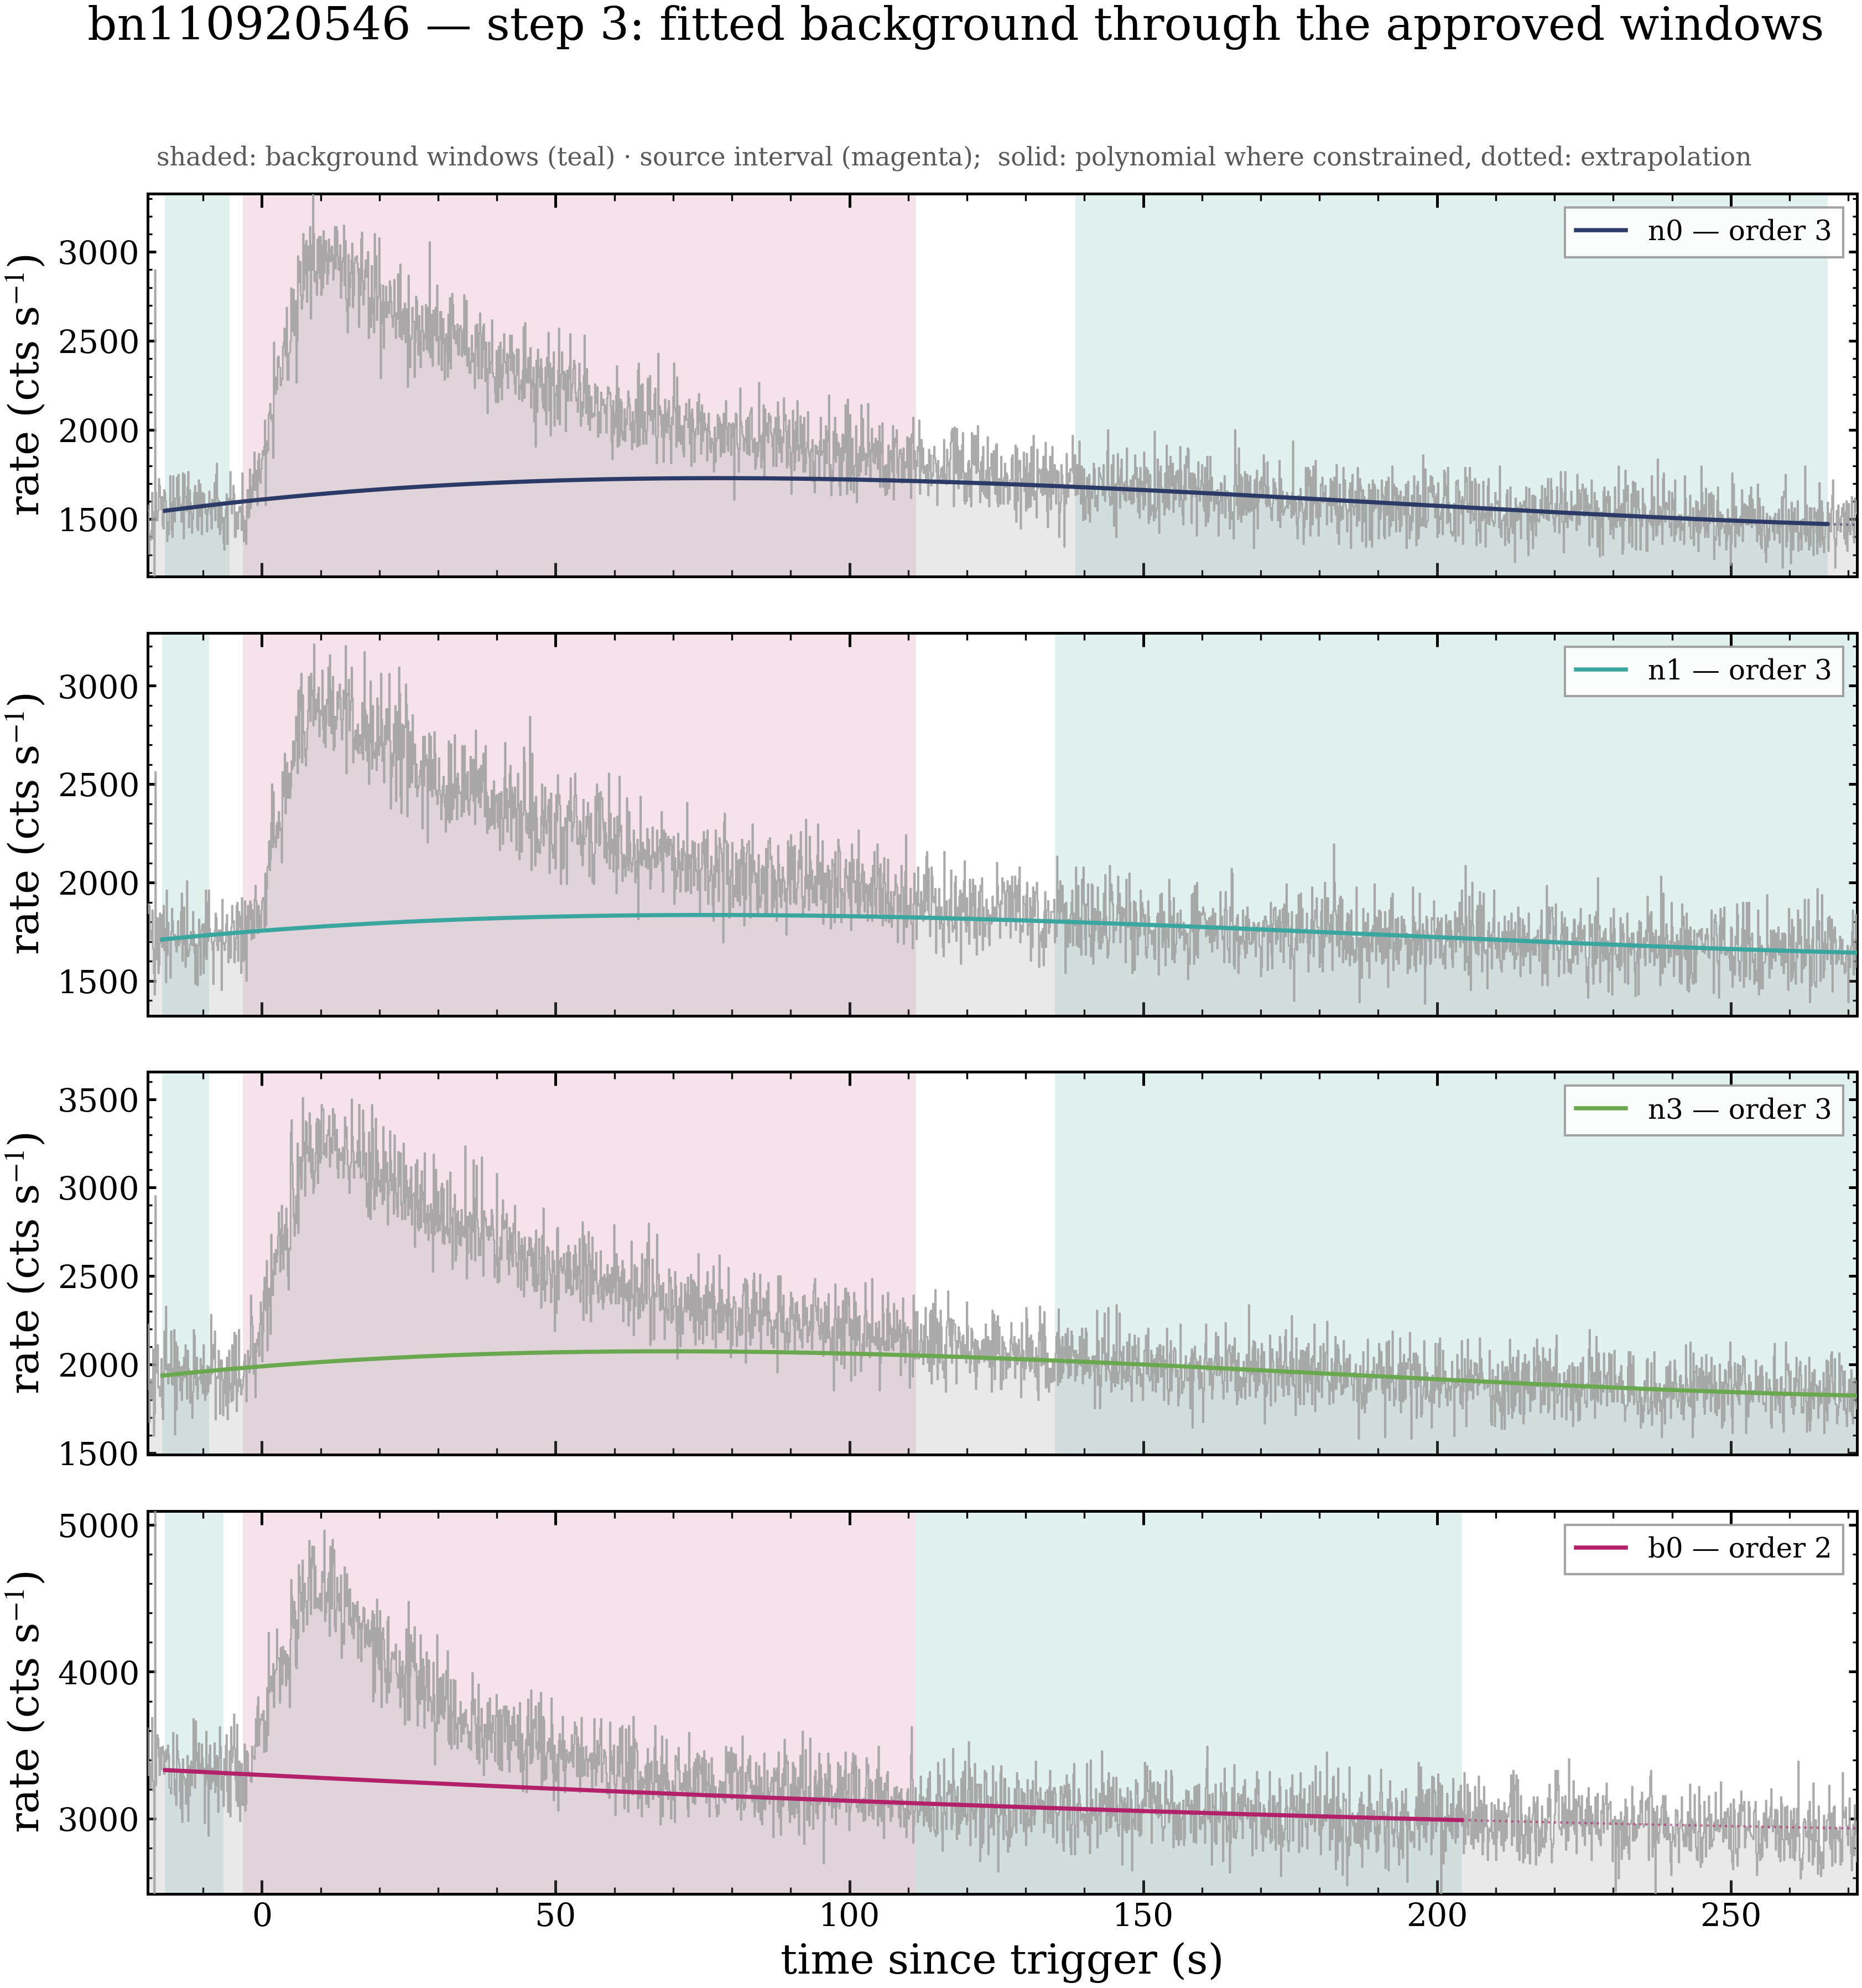

In [7]:
from IPython.display import Image, display
display(Image(filename=fig))

## 6. What may NOT be claimed from this step

Carried forward verbatim from the verifier's rounds, because a later reader will be tempted:

- **Not** "the background is good" — this panel has no residual strip and therefore no sigma
  scale. It shows *where* the windows are, not their quality.
- **Not** "the stall is handled everywhere" — it is out of the fitted windows, but still
  renders in the panel and is still clipped out of frame for n0 and b0.
- The on-figure "order N" is a **figure-local** estimator; production uses 3ML's automatic
  per-channel order (`POLY_ORDER = -1`). The two are different quantities.
- Parts of every post-window lie inside the catalogue T90. That is a **carried systematic**
  by PI ruling, not a defect — and per L33 the catalogue T90 is itself detector-specific and
  choice-laden, so it is context, not a measurement.

**Standing caveat for this burst:** Fermi left the South Atlantic Anomaly at t−T0 = −120.07 s,
so every pre-burst window sits in the activation-decay tail. Biltzinger+2020 use *this burst*
as their showcase that polynomial backgrounds can be ambiguous here. Per the PI's ruling of
2026-08-31, all background choices are **subjective to the user** until a physical background
model exists — so nothing in this step is presented as objectively correct, only as recorded,
reasoned and reproducible.